In [4]:
import numpy as np
import matplotlib.pyplot as plt

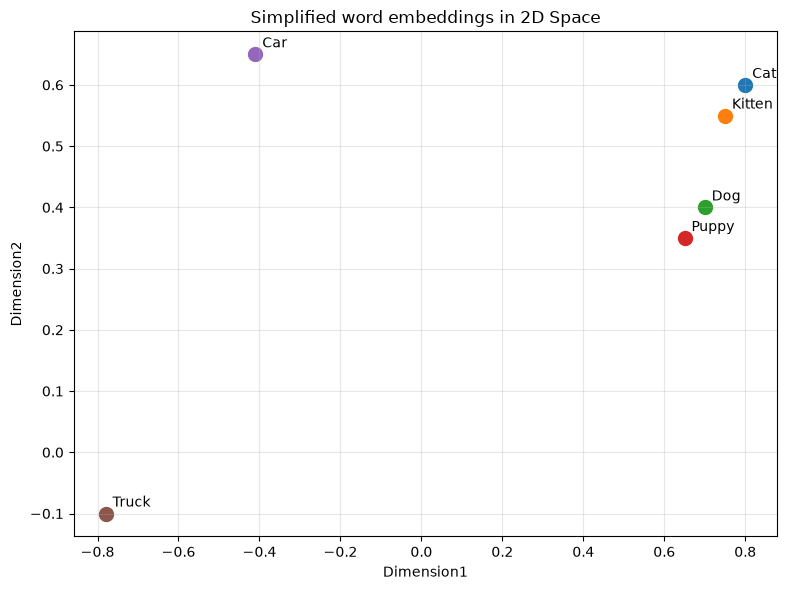

In [3]:
## Example of 2d embeddings and how close they are to each other

word_embeddings = {
    "Cat" : [0.8,0.6],
    "Kitten" : [0.75,0.55],
    "Dog" : [0.7,0.4],
    "Puppy" : [0.65, 0.35],
    "Car" : [-0.41, 0.65],
    "Truck" : [-0.78, -0.1]
}

fig , ax = plt.subplots(figsize = (8,6))

for word, cord in word_embeddings.items():

    ax.scatter(cord[0],cord[1],s = 100)
    ax.annotate(word, (cord[0],cord[1]), xytext = (5,5), textcoords = 'offset points')

ax.set_xlabel('Dimension1')
ax.set_ylabel('Dimension2')
ax.set_title("Simplified word embeddings in 2D Space")
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

In [11]:
def cosine_similarity(vec1,vec2):

    dot_product = np.dot(vec1,vec2)

    mag_vec1 = np.linalg.norm(vec1)
    mag_vec2 = np.linalg.norm(vec2)

    return (dot_product/ (mag_vec1 * mag_vec2))





cat = [0.8,0.7,0.4]
kitten = [0.75,0.65,0.35]
car = [-0.5,-0.2,0.7]

similarity = cosine_similarity(cat,car)

print(similarity)

-0.2591977286403177


Creating Embeddings with Hugging Face:

In [31]:
from langchain_huggingface import HuggingFaceEmbeddings

## No API key needed:

embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L12-v2",

)

embeddings

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12611.11it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L12-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [14]:
text = "Steve Jobs was the greatest visionary and genius the world has ever seen"

embedding = embeddings.embed_query(text)

print(embedding)
print(f"Length: {len(embedding)}")

[-0.02783733420073986, 0.08815526217222214, -0.052923500537872314, -0.0597878023982048, 0.00961989164352417, 0.023863349109888077, 0.06717855483293533, 0.022426266223192215, -0.032103508710861206, 0.001432636403478682, -0.0699293315410614, 0.07290249317884445, 0.04715883359313011, 0.05552717298269272, -0.06573857367038727, 0.09091563522815704, -0.03710031881928444, -0.012089488096535206, 4.510090730036609e-05, -0.10491941124200821, 0.024755671620368958, 0.0449821837246418, -0.003246207255870104, -0.009975536726415157, 0.010091251693665981, 0.13224802911281586, 0.004253230523318052, 0.04452896490693092, -0.02231033891439438, 0.005891445558518171, -0.01184306014329195, -0.01733468659222126, 0.03861366957426071, 0.043477173894643784, 0.04663284495472908, 0.05459979176521301, 0.010138795711100101, 0.06935415416955948, -0.04536008462309837, -0.07257451862096786, -0.00815754383802414, -0.020840821787714958, -0.06413731724023819, -0.00786171481013298, 0.024053895846009254, -0.0508757755160331

In [32]:
sentences = [
    "Steve Jobs is my role model",
    "मला भूक लागली आहे",
    "तुम्ही कसे आहात?",
    "¿Cómo estás? Espero que tengas un buen día."
]

embeds = embeddings.embed_documents(sentences)

for i , text in enumerate(sentences):
    print(f"Text{i+1}: {text}")
    print(f"Embedding: {embeds[i]}\n")

Text1: Steve Jobs is my role model
Embedding: [-0.013803118839859962, 0.021777264773845673, 0.04085798189043999, -0.04328461363911629, -0.05138867348432541, -0.021650025621056557, 0.1339714080095291, 0.016084332019090652, 0.020619837567210197, -0.011874206364154816, -0.06116684898734093, 0.00026608779444359243, -0.06739295274019241, 0.014090555720031261, 0.03698400408029556, 0.04481727257370949, 0.05675818398594856, -0.0029306882061064243, -0.03441639617085457, -0.023579547181725502, -0.05547964572906494, 0.025294585153460503, -0.020897241309285164, -0.027248604223132133, -0.018851388245821, 0.07262015342712402, -0.027932612225413322, 0.049507997930049896, -0.006505230441689491, -0.06427501142024994, -0.02802138961851597, -0.09147167205810547, 0.004708474036306143, 0.046691905707120895, 0.02773262932896614, 0.05415841564536095, -0.022561218589544296, 0.05125284194946289, -0.01867494359612465, -0.003076293272897601, -0.012854206375777721, 0.010335428640246391, 0.019228495657444, 0.05281

In [28]:
ans = cosine_similarity(embeds[1],embeds[4])
print(ans)

0.043563476799767645
